# The Loss Harness: What Happens Between Model Output and the Scalar

A causal-LM training harness, made **correct** and **observable**.

The starting point is these six lines:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss = cross_entropy(
    logits[:, :-1].reshape(-1, vocab_size),
    tokens[:, 1:].reshape(-1),
)
```

They are short, they run, and they never raise. That is exactly why they are dangerous.
Everything below exists to make each of those lines *checkable*.

* **Part 1** - seven checks on the harness: shapes, the shift verified on **strings**,
  padding masks, document packing, perplexity sanity, tied vs untied heads,
  and a hand-written chunked cross entropy measured against the ordinary one.
* **Part 2** - a second output head predicting token `t+2`, trained alongside the first.
* **Part 3** - the warning made concrete: shifting the target the **wrong way** produces a
  loss curve that looks *better* than the correct run while the model learns the wrong task.
  We reproduce the bug, plot the flattering curve, and then catch it by printing strings.

---
## 0. Setup

In [1]:
%matplotlib inline
import os, math, time, weakref, urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils._pytree
from torch.utils._python_dispatch import TorchDispatchMode
import matplotlib.pyplot as plt

os.makedirs("assets", exist_ok=True)
torch.set_num_threads(os.cpu_count() or 4)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337

def seed_all(s=SEED):
    torch.manual_seed(s)

seed_all()
print(f"torch      : {torch.__version__}")
print(f"device     : {DEVICE}")
print(f"cpu threads: {torch.get_num_threads()}")

# RESULTS collects every headline number, so the write-up cannot drift from the notebook.
RESULTS = {}

torch      : 2.11.0+cpu
device     : cpu
cpu threads: 8


### 0.1 Tokenizer

The real GPT-2 byte-level BPE tokenizer, vocab 50257. A real subword tokenizer matters
here: the whole point of Part 1 is reading **token strings**, and byte-level BPE makes
leading spaces and newlines visible as distinct tokens, which is precisely where
off-by-one bugs hide.

Rendering convention below: `U+2423` for a leading space, `U+23CE` for a newline.

In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
VOCAB_SIZE = len(tokenizer)
PAD_ID = tokenizer.eos_token_id  # GPT-2 has no pad token; we reuse <|endoftext|> as the pad *id*
IGNORE = -100                    # cross_entropy ignore_index: these positions contribute nothing

print(f"vocab_size : {VOCAB_SIZE}")
print(f"pad id     : {PAD_ID}  -> {tokenizer.convert_ids_to_tokens(PAD_ID)}")

def pretty(tok_str):
    """Render a GPT-2 byte-level token so whitespace is visible."""
    return tok_str.replace("Ġ", "␣").replace("Ċ", "⏎")

def tok_strings(ids):
    """ids -> list of human-readable token STRINGS (not ids)."""
    if torch.is_tensor(ids):
        ids = ids.detach().cpu().tolist()
    return [pretty(t) for t in tokenizer.convert_ids_to_tokens(ids)]

demo = tokenizer("The quick brown fox\njumps.", return_tensors="pt")["input_ids"][0]
print("\nsanity, one tokenized line:")
print("  ids    :", demo.tolist())
print("  strings:", tok_strings(demo))

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


vocab_size : 50257
pad id     : 50256  -> <|endoftext|>

sanity, one tokenized line:
  ids    : [464, 2068, 7586, 21831, 198, 73, 8142, 13]
  strings: ['The', '␣quick', '␣brown', '␣fox', '⏎', 'j', 'umps', '.']


### 0.2 Corpus

TinyShakespeare, downloaded once. If the download fails the notebook falls back to an
embedded passage so it still runs top to bottom offline.

In [3]:
FALLBACK = ("First Citizen:\nBefore we proceed any further, hear me speak.\n\n"
            "All:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die "
            "than to famish?\n\nAll:\nResolved. resolved.\n\n") * 400
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    TEXT = urllib.request.urlopen(URL, timeout=30).read().decode("utf-8")
    print(f"downloaded tinyshakespeare : {len(TEXT):,} chars")
except Exception as e:
    TEXT = FALLBACK
    print(f"download failed ({e}); using embedded fallback: {len(TEXT):,} chars")

CORPUS_IDS = torch.tensor(tokenizer(TEXT)["input_ids"], dtype=torch.long)
print(f"corpus tokens              : {CORPUS_IDS.numel():,}")

downloaded tinyshakespeare : 1,115,394 chars


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


corpus tokens              : 338,025


### 0.3 Model

A small causal transformer. Note the deliberate split, which mirrors the harness we were
handed: **`model` returns `hidden`, and `output_head` is a separate module.** Keeping them
separate is what makes the tied/untied comparison (check 6) and the chunked-loss rewrite
(check 7) possible at all. If the head is fused into the model, you cannot get at the
hidden states and neither check can be written.

In [4]:
D_MODEL, N_LAYER, N_HEAD, BLOCK = 256, 4, 4, 128
BATCH = 8
INIT_STD = 0.02

class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, h, batch_first=True)
        self.ln2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x, causal_mask):
        h = self.ln1(x)
        a, _ = self.attn(h, h, h, attn_mask=causal_mask, need_weights=False)
        x = x + a
        return x + self.mlp(self.ln2(x))

class TinyGPT(nn.Module):
    """Returns HIDDEN STATES, not logits. The output head lives outside the model."""
    def __init__(self, vocab=None, d=D_MODEL, n_layer=N_LAYER, n_head=N_HEAD,
                 block=BLOCK, init_std=INIT_STD):
        super().__init__()
        vocab = vocab or VOCAB_SIZE
        self.init_std = init_std
        self.tok_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Embedding(block, d)
        self.blocks = nn.ModuleList([Block(d, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(d)
        if init_std is not None:
            self.apply(self._init)

    def _init(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=self.init_std)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, tokens):
        B, T = tokens.shape
        mask = torch.triu(torch.ones(T, T, dtype=torch.bool, device=tokens.device), 1)
        x = self.tok_emb(tokens) + self.pos_emb(torch.arange(T, device=tokens.device))
        for b in self.blocks:
            x = b(x, mask)
        return self.ln_f(x)          # (B, T, D)

def make_head(model, tied, vocab=None, d=D_MODEL):
    vocab = vocab or VOCAB_SIZE
    head = nn.Linear(d, vocab, bias=False)
    if tied:
        head.weight = model.tok_emb.weight   # SHARED storage, not a copy
    else:
        nn.init.normal_(head.weight, std=INIT_STD)
    return head

seed_all()
model = TinyGPT().to(DEVICE)
output_head = make_head(model, tied=True).to(DEVICE)
print(f"trunk params (head tied to tok_emb): {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

trunk params (head tied to tok_emb): 16.06M


### 0.4 Batch sampler, the harness function, and a short reference training run

Checks 3 and 4 (padding, document boundaries) are only meaningful on a model that has
*learned something*. On a random model every loss is `ln(V)` and every masking difference
is noise. So we train a short reference model here and reuse it for those demos.
Check 5 deliberately uses a **fresh untrained** model instead.

In [5]:
def get_batch(batch=BATCH, block=BLOCK, data=None):
    data = CORPUS_IDS if data is None else data
    ix = torch.randint(0, data.numel() - block - 1, (batch,))
    return torch.stack([data[i:i + block] for i in ix]).to(DEVICE)

def shifted_ce(logits, tokens, ignore_index=IGNORE, reduction="mean"):
    """The harness exactly as given, with a mask-aware reduction."""
    return F.cross_entropy(
        logits[:, :-1].reshape(-1, logits.size(-1)),
        tokens[:, 1:].reshape(-1),
        ignore_index=ignore_index,
        reduction=reduction,
    )

REF_STEPS = 250
seed_all()
ref_model = TinyGPT().to(DEVICE)
ref_head = make_head(ref_model, tied=True).to(DEVICE)
ref_opt = torch.optim.AdamW(ref_model.parameters(), lr=3e-4)

t0 = time.time()
ref_curve = []
for step in range(REF_STEPS):
    tokens = get_batch()
    hidden = ref_model(tokens)
    logits = ref_head(hidden)
    loss = shifted_ce(logits, tokens)
    ref_opt.zero_grad(set_to_none=True)
    loss.backward()
    ref_opt.step()
    ref_curve.append(loss.item())
    if step % 20 == 0 or step == REF_STEPS - 1:
        print(f"  ref step {step:3d}  loss {loss.item():7.4f}")
print(f"reference model trained in {time.time()-t0:.1f}s "
      f"({ref_curve[0]:.3f} -> {ref_curve[-1]:.3f})")
ref_model.eval(); ref_head.eval()
print()

  ref step   0  loss 10.8533


  ref step  20  loss  8.5928


  ref step  40  loss  7.0012


  ref step  60  loss  6.6204


  ref step  80  loss  6.1917


...

  ref step 180  loss  5.9165


  ref step 200  loss  5.9568


  ref step 220  loss  5.8270


  ref step 240  loss  5.5834


  ref step 249  loss  5.5927
reference model trained in 306.6s (10.853 -> 5.593)



---
# Part 1

## Check 1 - Print every tensor shape, and say what each dimension is

Nothing exotic, but this is the cheapest bug detector in the file. Most harness bugs are
a `reshape` that silently succeeds because the element count happens to match.

In [6]:
tokens = get_batch(batch=4, block=16)

with torch.no_grad():
    hidden = ref_model(tokens)          # the model returns hidden states
    logits = ref_head(hidden)           # the head projects to vocabulary

pred_logits = logits[:, :-1]            # drop the last position: it has no target inside this window
targets     = tokens[:, 1:]             # drop the first token: it is never predicted
flat_logits = pred_logits.reshape(-1, VOCAB_SIZE)
flat_targets = targets.reshape(-1)

B, T = tokens.shape
rows = [
    ("tokens",       tuple(tokens.shape),
     f"(B={B} sequences in the batch, T={T} token positions per sequence)"),
    ("hidden",       tuple(hidden.shape),
     f"(B={B} sequences, T={T} positions, D={D_MODEL} residual-stream channels per position)"),
    ("logits",       tuple(logits.shape),
     f"(B={B} sequences, T={T} positions, V={VOCAB_SIZE} unnormalised scores, one per vocab entry)"),
    ("pred_logits",  tuple(pred_logits.shape),
     f"(B={B}, T-1={T-1} positions that HAVE a next token in-window, V={VOCAB_SIZE})"),
    ("targets",      tuple(targets.shape),
     f"(B={B}, T-1={T-1} next-token labels, target[b,i] is the token that follows tokens[b,i])"),
    ("flat_logits",  tuple(flat_logits.shape),
     f"(N=B*(T-1)={B*(T-1)} independent predictions, V={VOCAB_SIZE} classes each)"),
    ("flat_targets", tuple(flat_targets.shape),
     f"(N={B*(T-1)} class indices, one integer per prediction)"),
]
w = max(len(r[0]) for r in rows)
for name, shape, meaning in rows:
    print(f"{name:<{w}}  {str(shape):<18}  {meaning}")

assert flat_logits.shape[0] == flat_targets.shape[0], "row count mismatch: the shift is wrong"
print(f"\nrows fed to cross_entropy: {flat_logits.shape[0]}  "
      f"= B*(T-1) = {B}*{T-1}   [logits rows == target rows: OK]")
RESULTS["1_rows"] = flat_logits.shape[0]
RESULTS["1_shapes"] = {n: s for n, s, _ in rows}

tokens        (4, 16)             (B=4 sequences in the batch, T=16 token positions per sequence)
hidden        (4, 16, 256)        (B=4 sequences, T=16 positions, D=256 residual-stream channels per position)
logits        (4, 16, 50257)      (B=4 sequences, T=16 positions, V=50257 unnormalised scores, one per vocab entry)
pred_logits   (4, 15, 50257)      (B=4, T-1=15 positions that HAVE a next token in-window, V=50257)
targets       (4, 15)             (B=4, T-1=15 next-token labels, target[b,i] is the token that follows tokens[b,i])
flat_logits   (60, 50257)         (N=B*(T-1)=60 independent predictions, V=50257 classes each)
flat_targets  (60,)               (N=60 class indices, one integer per prediction)

rows fed to cross_entropy: 60  = B*(T-1) = 4*15   [logits rows == target rows: OK]


## Check 2 - Verify the shift by printing token STRINGS, inputs beside targets

> *"You will not catch an off-by-one in a wall of integers."*

The contract we are asserting: **the model reads `tokens[b, i]` and must predict
`tokens[b, i+1]`.** So the target string on row `i` must be the input string on row `i+1`.
Read the two columns below and you can see the whole table is the same sentence, offset by
exactly one row.

In [7]:
def show_shift(tokens_1d, delta=1, n=14, title=None):
    """Print input strings beside target strings for a given shift delta."""
    ids = tokens_1d.detach().cpu()
    inp = ids[:len(ids) - delta] if delta > 0 else ids[-delta:]
    tgt = ids[delta:] if delta > 0 else ids[:len(ids) + delta]
    si, st = tok_strings(inp), tok_strings(tgt)
    if title:
        print(title)
    print(f"{'pos':>4}  {'INPUT  logits row i reads this':<34}  {'TARGET  must predict this':<30}")
    print("-" * 74)
    for i in range(min(n, len(si))):
        print(f"{i:>4}  {repr(si[i]):<34}  {repr(st[i]):<30}")
    return si, st

seq = tokens[0]
si, st = show_shift(seq, delta=1, n=14,
                    title="shift = +1  (CORRECT: predict the NEXT token)\n")

# the assertion, not just the eyeball
ids = seq.detach().cpu().tolist()
mismatch = sum(1 for i in range(len(ids) - 1) if ids[i + 1] != ids[1:][i])
offset_ok = all(st[i] == si[i + 1] for i in range(len(si) - 1))
print("-" * 74)
print(f"target[i] == input[i+1] for every row : {offset_ok}")
print(f"mismatches found                      : {mismatch}")
print("\nreconstructed from the INPUT column :", repr("".join(si)[:70]))
print("reconstructed from the TARGET column:", repr("".join(st)[:70]))
print("\n-> the target column is the input column slid one row up. That is the shift, verified on text.")
RESULTS["2_offset_ok"] = bool(offset_ok)
RESULTS["2_mismatches"] = mismatch

shift = +1  (CORRECT: predict the NEXT token)

 pos  INPUT  logits row i reads this      TARGET  must predict this     
--------------------------------------------------------------------------
   0  'IL'                                'IA'                          
   1  'IA'                                ':'                           
   2  ':'                                 '⏎'                           
   3  '⏎'                                 'B'                           
   4  'B'                                 'es'                          
   5  'es'                                'ee'                          
   6  'ee'                                'ch'                          
   7  'ch'                                '␣you'                        
   8  '␣you'                              ','                           
   9  ','                                 '␣give'                       
  10  '␣give'                             '␣me'                         
  

## Check 3 - Mask padding, and confirm the count of contributing tokens changes

Two documents of different length in one batch. The short one is padded. If we do not mask,
cross entropy scores the pad positions too, and the reported number stops being the loss on
the task we care about.

**The direction of the error is not fixed, so do not memorise one.** It depends on how well
the model predicts pads. In a normal training run pads are frequent and `PAD -> PAD` is
trivial, so the unmasked loss is dragged **down** and the model looks better than it is.
Our reference model was trained on Shakespeare and has never once seen `<|endoftext|>`, so
for us the pad positions are *hard* and the unmasked loss is dragged **up** instead. Either
way it is wrong; the notebook prints which way it went rather than asserting one.

In [8]:
doc_a = tokenizer("To be, or not to be, that is the question:")["input_ids"]
doc_b = tokenizer("All the world is a stage.")["input_ids"]
T_pad = max(len(doc_a), len(doc_b))

padded = torch.full((2, T_pad), PAD_ID, dtype=torch.long)
padded[0, :len(doc_a)] = torch.tensor(doc_a)
padded[1, :len(doc_b)] = torch.tensor(doc_b)
attn = torch.zeros(2, T_pad, dtype=torch.bool)
attn[0, :len(doc_a)] = True
attn[1, :len(doc_b)] = True
padded, attn = padded.to(DEVICE), attn.to(DEVICE)

print(f"batch shape (B=2 docs, T={T_pad} padded positions): {tuple(padded.shape)}")
print(f"row 0 real tokens: {len(doc_a)},  row 1 real tokens: {len(doc_b)} "
      f"-> {T_pad - len(doc_b)} pad slots on row 1")
print("\nrow 1 as strings:", tok_strings(padded[1]))

# targets, unmasked then masked
tgt_unmasked = padded[:, 1:].clone()
tgt_masked = padded[:, 1:].clone()
tgt_masked[~attn[:, 1:]] = IGNORE           # a pad token is never a valid target

n_unmasked = tgt_unmasked.numel()
n_masked = int((tgt_masked != IGNORE).sum())

with torch.no_grad():
    lg = ref_head(ref_model(padded))
    loss_unmasked = F.cross_entropy(lg[:, :-1].reshape(-1, VOCAB_SIZE),
                                    tgt_unmasked.reshape(-1))
    loss_masked = F.cross_entropy(lg[:, :-1].reshape(-1, VOCAB_SIZE),
                                  tgt_masked.reshape(-1), ignore_index=IGNORE)

print(f"\ncontributing tokens WITHOUT mask : {n_unmasked}   (= B*(T-1) = 2*{T_pad-1})")
print(f"contributing tokens WITH    mask : {n_masked}   ({n_unmasked - n_masked} pad targets dropped)")
print(f"\nloss WITHOUT mask : {loss_unmasked.item():.4f}   <- averaged over {n_unmasked} rows, "
      f"{n_unmasked-n_masked} of which are pad->pad")
print(f"loss WITH    mask : {loss_masked.item():.4f}   <- averaged over {n_masked} real rows")
_dir = "UP" if loss_unmasked.item() > loss_masked.item() else "DOWN"
print(f"\nThe denominator changed, so the number changed. Here the pad positions drag the "
      f"reported loss {_dir}\nby {abs(loss_unmasked.item()-loss_masked.item()):.4f} nats, "
      f"because this model was never trained on {tokenizer.convert_ids_to_tokens(PAD_ID)} "
      f"and finds it\nhard to predict. A model that saw pads often would find them trivial "
      "and be dragged the other way.\nOnly the masked number is the loss on the task we "
      "care about.")
RESULTS["3_tokens_unmasked"] = n_unmasked
RESULTS["3_tokens_masked"] = n_masked
RESULTS["3_loss_unmasked"] = round(loss_unmasked.item(), 4)
RESULTS["3_loss_masked"] = round(loss_masked.item(), 4)

batch shape (B=2 docs, T=13 padded positions): (2, 13)


row 0 real tokens: 13,  row 1 real tokens: 7 -> 6 pad slots on row 1

row 1 as strings: ['All', '␣the', '␣world', '␣is', '␣a', '␣stage', '.', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>']

contributing tokens WITHOUT mask : 24   (= B*(T-1) = 2*12)
contributing tokens WITH    mask : 18   (6 pad targets dropped)

loss WITHOUT mask : 7.3775   <- averaged over 24 rows, 6 of which are pad->pad
loss WITH    mask : 5.2811   <- averaged over 18 real rows

The denominator changed, so the number changed. Here the pad positions drag the reported loss UP
by 2.0963 nats, because this model was never trained on <|endoftext|> and finds it
hard to predict. A model that saw pads often would find them trivial and be dragged the other way.
Only the masked number is the loss on the task we care about.


## Check 4 - Pack two documents into one sequence and mask the boundary

Packing is how you avoid wasting compute on padding: concatenate documents until the
sequence is full. The cost is one poisoned position - the pair whose **input is the last
token of document A** and whose **target is the first token of document B**. That target
is unknowable from the context; asking the model to predict it is asking it to guess which
document the shuffler picked next.

We print that one pair as strings, then show the loss with and without it, and reconcile
the two numbers arithmetically.

In [9]:
text_a = "The cat sat on the mat and purred softly in the afternoon sun."
text_b = "Quarterly revenue increased by twelve percent across all regions."
ids_a = tokenizer(text_a)["input_ids"]
ids_b = tokenizer(text_b)["input_ids"]
packed = torch.tensor(ids_a + ids_b, dtype=torch.long)[None, :].to(DEVICE)
doc_id = torch.tensor([0] * len(ids_a) + [1] * len(ids_b), dtype=torch.long)[None, :].to(DEVICE)

Tp = packed.shape[1]
print(f"packed shape (B=1 sequence, T={Tp} positions): {tuple(packed.shape)}")
print(f"doc A occupies positions 0..{len(ids_a)-1}, doc B occupies {len(ids_a)}..{Tp-1}\n")

# the boundary pair, in strings
bi = len(ids_a) - 1                      # index into the (T-1) prediction rows
inp_s = tok_strings(packed[0, :-1])
tgt_s = tok_strings(packed[0, 1:])
print("the neighbourhood of the seam (prediction rows):")
print(f"{'row':>4}  {'INPUT':<16}  {'TARGET':<16}")
print("-" * 42)
for i in range(bi - 2, bi + 3):
    flag = "   <== BOUNDARY: last token of A -> first token of B" if i == bi else ""
    print(f"{i:>4}  {repr(inp_s[i]):<16}  {repr(tgt_s[i]):<16}{flag}")

# losses
tgt_all = packed[:, 1:].clone()
tgt_cut = packed[:, 1:].clone()
cross = doc_id[:, 1:] != doc_id[:, :-1]  # True exactly where the target starts a new document
tgt_cut[cross] = IGNORE

with torch.no_grad():
    lgp = ref_head(ref_model(packed))
    per_tok = F.cross_entropy(lgp[:, :-1].reshape(-1, VOCAB_SIZE),
                              tgt_all.reshape(-1), reduction="none")
    loss_with = per_tok.mean()
    loss_without = F.cross_entropy(lgp[:, :-1].reshape(-1, VOCAB_SIZE),
                                   tgt_cut.reshape(-1), ignore_index=IGNORE)

N = per_tok.numel()
boundary_loss = per_tok[bi].item()
print(f"\ncontributing tokens WITH boundary    : {N}")
print(f"contributing tokens WITHOUT boundary : {int((tgt_cut != IGNORE).sum())}")
print(f"\nloss WITH    boundary : {loss_with.item():.4f}")
print(f"loss WITHOUT boundary : {loss_without.item():.4f}")
print(f"difference            : {loss_with.item() - loss_without.item():+.4f}")
print(f"\nthe boundary pair alone costs {boundary_loss:.4f} nats "
      f"(vs {loss_without.item():.4f} average elsewhere)")
check = (per_tok.sum().item() - boundary_loss) / (N - 1)
print(f"reconciliation: (sum - boundary)/(N-1) = {check:.4f}  == masked loss {loss_without.item():.4f}")
RESULTS["4_loss_with_boundary"] = round(loss_with.item(), 4)
RESULTS["4_loss_without_boundary"] = round(loss_without.item(), 4)
RESULTS["4_boundary_token_loss"] = round(boundary_loss, 4)

packed shape (B=1 sequence, T=27 positions): (1, 27)
doc A occupies positions 0..14, doc B occupies 15..26

the neighbourhood of the seam (prediction rows):
 row  INPUT             TARGET          
------------------------------------------
  12  '␣afternoon'      '␣sun'          
  13  '␣sun'            '.'             
  14  '.'               'Qu'               <== BOUNDARY: last token of A -> first token of B
  15  'Qu'              'arter'         
  16  'arter'           'ly'            

contributing tokens WITH boundary    : 26
contributing tokens WITHOUT boundary : 25

loss WITH    boundary : 8.8670
loss WITHOUT boundary : 8.6823
difference            : +0.1846

the boundary pair alone costs 13.4828 nats (vs 8.6823 average elsewhere)
reconciliation: (sum - boundary)/(N-1) = 8.6823  == masked loss 8.6823


One seam on a small model is an anecdote, not evidence - the difference above is a single
sample and could be noise. So we repeat the experiment over many real document pairs drawn
from the corpus and compare the *mean* loss at seam positions against the mean everywhere else.

In [10]:
paras = [p.strip() for p in TEXT.split("\n\n") if 120 < len(p.strip()) < 900]
print(f"usable documents in corpus: {len(paras)}")

N_SEAMS, SEAM_BLOCK = 64, 96
g = torch.Generator().manual_seed(7)
seqs, seam_pos = [], []
for _ in range(N_SEAMS):
    i, j = torch.randint(0, len(paras), (2,), generator=g).tolist()
    a = tokenizer(paras[i])["input_ids"]
    b = tokenizer(paras[j])["input_ids"]
    if len(a) < 8 or len(b) < 8:
        continue
    a = a[:SEAM_BLOCK // 2]
    b = b[:SEAM_BLOCK - len(a)]
    if len(a) + len(b) < SEAM_BLOCK:
        continue
    seqs.append(torch.tensor(a + b))
    seam_pos.append(len(a) - 1)          # prediction-row index of the seam

seam_batch = torch.stack(seqs).to(DEVICE)
seam_idx = torch.tensor(seam_pos, device=DEVICE)
Bs, Ts = seam_batch.shape
print(f"built {Bs} packed sequences of {Ts} tokens, one document seam in each\n")

with torch.no_grad():
    lg_s = ref_head(ref_model(seam_batch))
    pt = F.cross_entropy(lg_s[:, :-1].reshape(-1, VOCAB_SIZE),
                         seam_batch[:, 1:].reshape(-1),
                         reduction="none").view(Bs, Ts - 1)

is_seam = torch.zeros_like(pt, dtype=torch.bool)
is_seam[torch.arange(Bs, device=DEVICE), seam_idx] = True

seam_mean = pt[is_seam].mean().item()
interior_mean = pt[~is_seam].mean().item()
all_mean = pt.mean().item()
masked_mean = pt[~is_seam].mean().item()
frac_higher = (pt[is_seam] > pt[~is_seam].mean()).float().mean().item()

print(f"{'positions':<26}{'count':>10}{'mean loss':>14}")
print("-" * 52)
print(f"{'document seams':<26}{int(is_seam.sum()):>10}{seam_mean:>14.4f}")
print(f"{'everywhere else':<26}{int((~is_seam).sum()):>10}{interior_mean:>14.4f}")
print("-" * 52)
print(f"seam positions cost {seam_mean - interior_mean:+.4f} nats more than ordinary positions "
      f"({seam_mean/interior_mean:.2f}x)")
print(f"{frac_higher*100:.0f}% of individual seams score above the interior mean")
print(f"\nloss over all positions      (seams INCLUDED) : {all_mean:.4f}")
print(f"loss with seams masked out   (seams EXCLUDED) : {masked_mean:.4f}")
print(f"difference                                    : {all_mean - masked_mean:+.4f}")
RESULTS["4agg_n_seams"] = int(is_seam.sum())
RESULTS["4agg_seam_mean"] = round(seam_mean, 4)
RESULTS["4agg_interior_mean"] = round(interior_mean, 4)
RESULTS["4agg_loss_with"] = round(all_mean, 4)
RESULTS["4agg_loss_without"] = round(masked_mean, 4)

usable documents in corpus: 2448


built 47 packed sequences of 96 tokens, one document seam in each



positions                      count     mean loss
----------------------------------------------------
document seams                    47        9.2080
everywhere else                 4418        5.8235
----------------------------------------------------
seam positions cost +3.3846 nats more than ordinary positions (1.58x)
100% of individual seams score above the interior mean

loss over all positions      (seams INCLUDED) : 5.8591
loss with seams masked out   (seams EXCLUDED) : 5.8235
difference                                    : +0.0356


**Explaining the difference.** The masked loss is the *unmasked* loss with one term removed
from the numerator and one from the denominator. The boundary term is far above the average,
because `.` -> `Quarterly` is not a language-modelling fact - it is an artefact of how the
documents happened to be concatenated. Leaving it in does two bad things: it inflates the
reported loss (cosmetic), and it sends gradient telling the model that arbitrary topic jumps
after a period are likely (substantive). At scale, with thousands of seams per batch, that
second effect is the one that hurts. Production packing also resets position ids and blocks
attention across the seam; masking the target is the minimum correct step.

## Check 5 - Perplexity, and an untrained model near vocabulary size

An untrained model is a uniform distribution over the vocabulary. Uniform over `V` classes
gives loss `ln(V)` and perplexity `exp(ln V) = V`. So **an untrained model whose perplexity
is not close to `V` has a bug**, and this check has to pass before any curve means anything.

We first show the check *catching a real bug*: PyTorch default initialisation of
`nn.Embedding` is `N(0, 1)`, and with a tied head the logits become `h @ E.T` with
huge variance. The loss is enormous and perplexity is absurd. Then we fix the init.

In [11]:
def perplexity_of(m, h, n_batches=6):
    m.eval(); h.eval()
    tot, cnt = 0.0, 0
    with torch.no_grad():
        for _ in range(n_batches):
            tk = get_batch()
            lg = h(m(tk))
            l = shifted_ce(lg, tk, reduction="sum")
            tot += l.item(); cnt += tk[:, 1:].numel()
    mean = tot / cnt
    return mean, math.exp(min(mean, 700))

print(f"target: an untrained model should sit at loss ln(V) = {math.log(VOCAB_SIZE):.4f}, "
      f"perplexity ~ V = {VOCAB_SIZE}\n")

# (a) the BUG: default init
seed_all()
bad_model = TinyGPT(init_std=None).to(DEVICE)      # leave PyTorch defaults in place
bad_head = make_head(bad_model, tied=True).to(DEVICE)
bl, bp = perplexity_of(bad_model, bad_head)
print(f"[BUGGY  default init ] loss {bl:9.4f}   perplexity {bp:.3e}   ratio to V: {bp/VOCAB_SIZE:.3e}")
print("        -> perplexity is astronomically above V. Something is wrong; do NOT train this.")
print("        -> cause: nn.Embedding defaults to N(0,1); tied logits h @ E.T blow up.\n")

# (b) the FIX: std = 0.02
seed_all()
good_model = TinyGPT(init_std=0.02).to(DEVICE)
good_head = make_head(good_model, tied=True).to(DEVICE)
gl, gp = perplexity_of(good_model, good_head)
print(f"[FIXED  std=0.02 init] loss {gl:9.4f}   perplexity {gp:9.1f}   ratio to V: {gp/VOCAB_SIZE:.4f}")
print(f"        -> ln(V) = {math.log(VOCAB_SIZE):.4f}, measured {gl:.4f}; "
      f"perplexity {gp:.1f} vs V = {VOCAB_SIZE}. The harness is trustworthy.\n")

tl, tp = perplexity_of(ref_model, ref_head)
print(f"[trained {REF_STEPS} steps    ] loss {tl:9.4f}   perplexity {tp:9.1f}   "
      f"ratio to V: {tp/VOCAB_SIZE:.4f}")
RESULTS["5_ln_vocab"] = round(math.log(VOCAB_SIZE), 4)
RESULTS["5_untrained_loss"] = round(gl, 4)
RESULTS["5_untrained_ppl"] = round(gp, 1)
RESULTS["5_ppl_over_vocab"] = round(gp / VOCAB_SIZE, 4)
RESULTS["5_buggy_ppl"] = f"{bp:.3e}"
RESULTS["5_trained_ppl"] = round(tp, 1)

target: an untrained model should sit at loss ln(V) = 10.8249, perplexity ~ V = 50257



[BUGGY  default init ] loss  168.5983   perplexity 1.665e+73   ratio to V: 3.312e+68
        -> perplexity is astronomically above V. Something is wrong; do NOT train this.
        -> cause: nn.Embedding defaults to N(0,1); tied logits h @ E.T blow up.



[FIXED  std=0.02 init] loss   10.8574   perplexity   51917.5   ratio to V: 1.0330
        -> ln(V) = 10.8249, measured 10.8574; perplexity 51917.5 vs V = 50257. The harness is trustworthy.



[trained 250 steps    ] loss    5.5269   perplexity     251.4   ratio to V: 0.0050


## Check 6 - Tied vs untied output head, parameter counts on this configuration

In [12]:
seed_all()
m_tied = TinyGPT()
h_tied = make_head(m_tied, tied=True)
seed_all()
m_untied = TinyGPT()
h_untied = make_head(m_untied, tied=False)

def count(m, h):
    # a set of ids, so a tied head is not double counted
    seen, tot = set(), 0
    for p in list(m.parameters()) + list(h.parameters()):
        if id(p) in seen:
            continue
        seen.add(id(p)); tot += p.numel()
    return tot

n_tied, n_untied = count(m_tied, h_tied), count(m_untied, h_untied)
head_params = VOCAB_SIZE * D_MODEL
print(f"config: V={VOCAB_SIZE}, D={D_MODEL}, layers={N_LAYER}, heads={N_HEAD}, block={BLOCK}\n")
print(f"head weight is the same object as tok_emb.weight (tied) : "
      f"{h_tied.weight is m_tied.tok_emb.weight}")
print(f"head weight is the same object as tok_emb.weight (untied): "
      f"{h_untied.weight is m_untied.tok_emb.weight}\n")
print(f"tied   total parameters : {n_tied:>12,}  ({n_tied/1e6:.2f}M)")
print(f"untied total parameters : {n_untied:>12,}  ({n_untied/1e6:.2f}M)")
print(f"difference              : {n_untied-n_tied:>12,}  (= V*D = {VOCAB_SIZE}*{D_MODEL} "
      f"= {head_params:,})")
print(f"untied is {n_untied/n_tied:.2f}x the tied model; the extra matrix alone is "
      f"{head_params/n_untied*100:.1f}% of the untied total")
print(f"\nfor scale: the transformer blocks are only "
      f"{sum(p.numel() for p in m_tied.blocks.parameters()):,} parameters "
      f"({sum(p.numel() for p in m_tied.blocks.parameters())/n_tied*100:.1f}% of the tied model). "
      "At this size the model is mostly vocabulary.")
RESULTS["6_tied_params"] = n_tied
RESULTS["6_untied_params"] = n_untied
RESULTS["6_delta_params"] = n_untied - n_tied

config: V=50257, D=256, layers=4, heads=4, block=128

head weight is the same object as tok_emb.weight (tied) : True
head weight is the same object as tok_emb.weight (untied): False

tied   total parameters :   16,058,112  (16.06M)
untied total parameters :   28,923,904  (28.92M)
difference              :   12,865,792  (= V*D = 50257*256 = 12,865,792)
untied is 1.80x the tied model; the extra matrix alone is 44.5% of the untied total

for scale: the transformer blocks are only 3,159,040 parameters (19.7% of the tied model). At this size the model is mostly vocabulary.


## Check 7 - Peak memory: ordinary cross entropy vs a chunked version

The `(B, T, V)` logits tensor is usually the single largest allocation in a language-model
step. Ordinary cross entropy materialises it, then `log_softmax` materialises another tensor
the same size, then backward materialises the gradient - three copies of `B*T*V` floats.

The chunked version below never holds more than one slice. It is a real
`torch.autograd.Function`: the forward computes each slice of logits, folds it into the loss
sum, and **throws the slice away**; the backward **recomputes** that slice and turns it
straight into `grad_hidden` and `grad_weight`. We trade a second matmul for the peak.

In [13]:
class ChunkedCrossEntropy(torch.autograd.Function):
    """Cross entropy over hidden @ W.T without ever materialising all the logits."""

    @staticmethod
    def forward(ctx, hidden_flat, weight, targets_flat, ignore_index, n_chunks):
        ctx.save_for_backward(hidden_flat, weight, targets_flat)
        ctx.ignore_index, ctx.n_chunks = ignore_index, n_chunks
        n_valid = (targets_flat != ignore_index).sum().clamp(min=1)
        ctx.n_valid = n_valid
        total = hidden_flat.new_zeros(())
        for hc, tc in zip(hidden_flat.chunk(n_chunks), targets_flat.chunk(n_chunks)):
            logits = hc @ weight.t()                     # (chunk, V)  <- the only big tensor
            total = total + F.cross_entropy(logits, tc, ignore_index=ignore_index,
                                            reduction="sum")
            del logits                                   # freed before the next slice
        return total / n_valid

    @staticmethod
    def backward(ctx, grad_out):
        hidden_flat, weight, targets_flat = ctx.saved_tensors
        scale = grad_out / ctx.n_valid
        g_h = torch.empty_like(hidden_flat)
        g_W = torch.zeros_like(weight)
        off = 0
        for hc, tc in zip(hidden_flat.chunk(ctx.n_chunks), targets_flat.chunk(ctx.n_chunks)):
            n = hc.shape[0]
            logits = hc @ weight.t()                     # recomputed, not stored
            p = torch.softmax(logits, dim=-1)
            valid = (tc != ctx.ignore_index)
            p[torch.arange(n, device=p.device), tc.clamp(min=0)] -= 1.0   # dL/dlogits
            # every step below is in-place: a `g_W += p.t() @ hc` here would allocate a
            # second full V*D temporary per chunk and wipe out the entire saving.
            p.mul_(valid.unsqueeze(1).to(p.dtype)).mul_(scale)
            g_h[off:off + n] = p @ weight
            g_W.addmm_(p.t(), hc)
            off += n
            del logits, p
        return g_h, g_W, None, None, None

def chunked_ce(hidden_flat, weight, targets_flat, ignore_index=IGNORE, n_chunks=16):
    return ChunkedCrossEntropy.apply(hidden_flat, weight, targets_flat, ignore_index, n_chunks)

### 7a. Correctness first. A memory saving that changes the answer is not a saving.

In [14]:
seed_all()
Bm, Tm, N_CHUNKS = 4, 256, 16
h_ref = torch.randn(Bm * Tm, D_MODEL, device=DEVICE) * 0.5
W_ref = (torch.randn(VOCAB_SIZE, D_MODEL, device=DEVICE) * 0.02)
t_ref = torch.randint(0, VOCAB_SIZE, (Bm * Tm,), device=DEVICE)
t_ref[::17] = IGNORE                      # include masked rows in the correctness check

hA = h_ref.clone().requires_grad_(); WA = W_ref.clone().requires_grad_()
hB = h_ref.clone().requires_grad_(); WB = W_ref.clone().requires_grad_()

loss_a = F.cross_entropy(hA @ WA.t(), t_ref, ignore_index=IGNORE)
loss_a.backward()
loss_b = chunked_ce(hB, WB, t_ref, n_chunks=N_CHUNKS)
loss_b.backward()

print(f"ordinary loss : {loss_a.item():.8f}")
print(f"chunked  loss : {loss_b.item():.8f}")
print(f"|dloss|       : {abs(loss_a.item()-loss_b.item()):.3e}")
print(f"max |d grad_hidden| : {(hA.grad - hB.grad).abs().max().item():.3e}")
print(f"max |d grad_weight| : {(WA.grad - WB.grad).abs().max().item():.3e}")
print("\n-> same loss, same gradients. Now we can talk about memory.")
RESULTS["7_grad_max_diff"] = f"{max((hA.grad-hB.grad).abs().max().item(), (WA.grad-WB.grad).abs().max().item()):.2e}"

ordinary loss : 10.84114742
chunked  loss : 10.84114742
|dloss|       : 0.000e+00
max |d grad_hidden| : 9.459e-11
max |d grad_weight| : 2.095e-09

-> same loss, same gradients. Now we can talk about memory.


### 7b. Peak memory measurement

On CUDA we use `torch.cuda.max_memory_allocated`, which is exact. On CPU there is no such
counter, so we install a `TorchDispatchMode` that watches every tensor allocation and
records the high-water mark of live tensor bytes. Both paths measure the same thing:
the largest amount of tensor memory alive at any instant during forward + backward.

In [15]:
class PeakMemCPU(TorchDispatchMode):
    """High-water mark of live tensor bytes, for the CPU path."""
    def __init__(self):
        self.live, self.cur, self.peak, self._refs = {}, 0, 0, []

    def _reg(self, t):
        if not isinstance(t, torch.Tensor):
            return
        try:
            st = t.untyped_storage()
        except Exception:
            return
        p = st.data_ptr()
        if p == 0 or p in self.live:
            return
        self.live[p] = st.nbytes()
        self.cur += self.live[p]
        self.peak = max(self.peak, self.cur)
        def freed(_, p=p):
            self.cur -= self.live.pop(p, 0)
        self._refs.append(weakref.ref(t, freed))

    def __torch_dispatch__(self, func, types, args=(), kwargs=None):
        out = func(*args, **(kwargs or {}))
        torch.utils._pytree.tree_map_only(torch.Tensor, self._reg, out)
        return out

def measure_peak(fn):
    """Run fn(), return (loss_value, peak_bytes_attributable_to_fn).

    Both paths must measure the SAME thing: memory allocated *by this call*.
    torch.cuda.max_memory_allocated() is an absolute session figure - by this point
    the session already holds several trained models and their optimizer states, and
    counting that constant baseline on both sides silently crushes the ratio toward
    1.0x. So we subtract the baseline. The CPU tracker only sees tensors born inside
    the mode, so it is already a delta and needs no correction.
    """
    import gc
    if DEVICE == "cuda":
        gc.collect()
        torch.cuda.synchronize(); torch.cuda.empty_cache()
        base = torch.cuda.memory_allocated()          # everything already resident
        torch.cuda.reset_peak_memory_stats()
        v = fn()
        torch.cuda.synchronize()
        return v, torch.cuda.max_memory_allocated() - base
    with PeakMemCPU() as pm:
        v = fn()
    return v, pm.peak

MB = 1 << 20
logits_bytes = Bm * Tm * VOCAB_SIZE * 4
print(f"measurement config: B={Bm}, T={Tm}, D={D_MODEL}, V={VOCAB_SIZE}, chunks={N_CHUNKS}")
print(f"a full (B,T,V) fp32 logits tensor is {Bm}*{Tm}*{VOCAB_SIZE}*4 bytes "
      f"= {logits_bytes/MB:.1f} MB")
print(f"one chunk of logits is {logits_bytes/N_CHUNKS/MB:.1f} MB\n")

def run_ordinary():
    h = h_ref.clone().requires_grad_(); W = W_ref.clone().requires_grad_()
    l = F.cross_entropy(h @ W.t(), t_ref, ignore_index=IGNORE)
    l.backward()
    return l.item()

def run_chunked():
    h = h_ref.clone().requires_grad_(); W = W_ref.clone().requires_grad_()
    l = chunked_ce(h, W, t_ref, n_chunks=N_CHUNKS)
    l.backward()
    return l.item()

lo, peak_ord = measure_peak(run_ordinary)
lc, peak_chk = measure_peak(run_chunked)

print(f"ordinary cross entropy : peak {peak_ord/MB:8.2f} MB   (loss {lo:.4f})")
print(f"chunked  cross entropy : peak {peak_chk/MB:8.2f} MB   (loss {lc:.4f})")
print(f"\nratio ordinary/chunked : {peak_ord/peak_chk:.2f}x   "
      f"(saved {(peak_ord-peak_chk)/MB:.1f} MB, {(1-peak_chk/peak_ord)*100:.1f}%)")
print("\nThe floor for the chunked version is grad_weight, which is V*D*4 = "
      f"{VOCAB_SIZE*D_MODEL*4/MB:.1f} MB and cannot be chunked away - it is a real parameter "
      "gradient. Everything above that floor is logits, and that is what chunking removes.")
RESULTS["7_peak_ordinary_mb"] = round(peak_ord / MB, 2)
RESULTS["7_peak_chunked_mb"] = round(peak_chk / MB, 2)
RESULTS["7_ratio"] = round(peak_ord / peak_chk, 2)
RESULTS["7_measurement"] = "torch.cuda.max_memory_allocated" if DEVICE == "cuda" else "TorchDispatchMode live-byte high-water mark"

measurement config: B=4, T=256, D=256, V=50257, chunks=16
a full (B,T,V) fp32 logits tensor is 4*256*50257*4 bytes = 196.3 MB
one chunk of logits is 12.3 MB



ordinary cross entropy : peak   639.03 MB   (loss 10.8411)
chunked  cross entropy : peak   124.77 MB   (loss 10.8411)

ratio ordinary/chunked : 5.12x   (saved 514.3 MB, 80.5%)

The floor for the chunked version is grad_weight, which is V*D*4 = 49.1 MB and cannot be chunked away - it is a real parameter gradient. Everything above that floor is logits, and that is what chunking removes.


---
# Part 2 - A second output head predicting token `t+2`

Same trunk, two heads:

* `head_next` reads `hidden[:, i]` and predicts `tokens[:, i+1]` - logits `[:, :-1]` vs targets `[:, 1:]`
* `head_skip` reads `hidden[:, i]` and predicts `tokens[:, i+2]` - logits `[:, :-2]` vs targets `[:, 2:]`

The second head sees strictly less information about its target: to predict `t+2` it must
marginalise over the token at `t+1` that it is not told. So we expect `loss_skip > loss_next`
at every point in training. The interesting question is what the **gap** does.

In [16]:
P2_STEPS = 220
seed_all()
mt_model = TinyGPT().to(DEVICE)
head_next = make_head(mt_model, tied=True).to(DEVICE)     # t+1, tied to the embedding
head_skip = make_head(mt_model, tied=False).to(DEVICE)    # t+2, its own matrix
mt_opt = torch.optim.AdamW(
    list(mt_model.parameters()) + list(head_skip.parameters()), lr=3e-4)

print(f"trunk        : {sum(p.numel() for p in mt_model.parameters()):,} params")
print(f"head_next    : tied to tok_emb, 0 extra params")
print(f"head_skip    : {head_skip.weight.numel():,} extra params\n")

hist = {"next": [], "skip": [], "sum": []}
t0 = time.time()
for step in range(P2_STEPS):
    tk = get_batch()
    hidden = mt_model(tk)

    logits_next = head_next(hidden)
    loss_next = F.cross_entropy(
        logits_next[:, :-1].reshape(-1, VOCAB_SIZE), tk[:, 1:].reshape(-1),
        ignore_index=IGNORE)

    logits_skip = head_skip(hidden)
    loss_skip = F.cross_entropy(
        logits_skip[:, :-2].reshape(-1, VOCAB_SIZE), tk[:, 2:].reshape(-1),
        ignore_index=IGNORE)

    loss_total = loss_next + loss_skip
    mt_opt.zero_grad(set_to_none=True)
    loss_total.backward()
    mt_opt.step()

    hist["next"].append(loss_next.item())
    hist["skip"].append(loss_skip.item())
    hist["sum"].append(loss_total.item())
    if step % 20 == 0 or step == P2_STEPS - 1:
        print(f"  step {step:3d}  loss_next {loss_next.item():7.4f}   "
              f"loss_skip {loss_skip.item():7.4f}   sum {loss_total.item():7.4f}   "
              f"gap {loss_skip.item()-loss_next.item():+.4f}")
print(f"\ntrained {P2_STEPS} steps in {time.time()-t0:.1f}s")

trunk        : 16,058,112 params
head_next    : tied to tok_emb, 0 extra params
head_skip    : 12,865,792 extra params



  step   0  loss_next 10.8810   loss_skip 10.8630   sum 21.7440   gap -0.0180


  step  20  loss_next  8.6412   loss_skip  8.6106   sum 17.2518   gap -0.0306


  step  40  loss_next  7.2014   loss_skip  7.1742   sum 14.3756   gap -0.0272


  step  60  loss_next  6.5123   loss_skip  6.6069   sum 13.1191   gap +0.0946


...

  step 140  loss_next  6.3561   loss_skip  6.5704   sum 12.9265   gap +0.2143


  step 160  loss_next  6.0289   loss_skip  6.2735   sum 12.3024   gap +0.2446


  step 180  loss_next  5.8322   loss_skip  6.0484   sum 11.8806   gap +0.2162


  step 200  loss_next  5.8377   loss_skip  6.1197   sum 11.9574   gap +0.2820


  step 219  loss_next  5.9620   loss_skip  6.3040   sum 12.2660   gap +0.3420

trained 220 steps in 418.1s


                         loss_next (t+1)   loss_skip (t+2)       gap
--------------------------------------------------------------------
first 20 steps                    9.7376            9.7052   -0.0325
last 20 steps                     5.8013            6.0979   +0.2966
perplexity (last)                  330.7             444.9

sum of the two losses (last 20 steps): 11.8992
total drop: next 3.9364 nats, skip 3.6073 nats


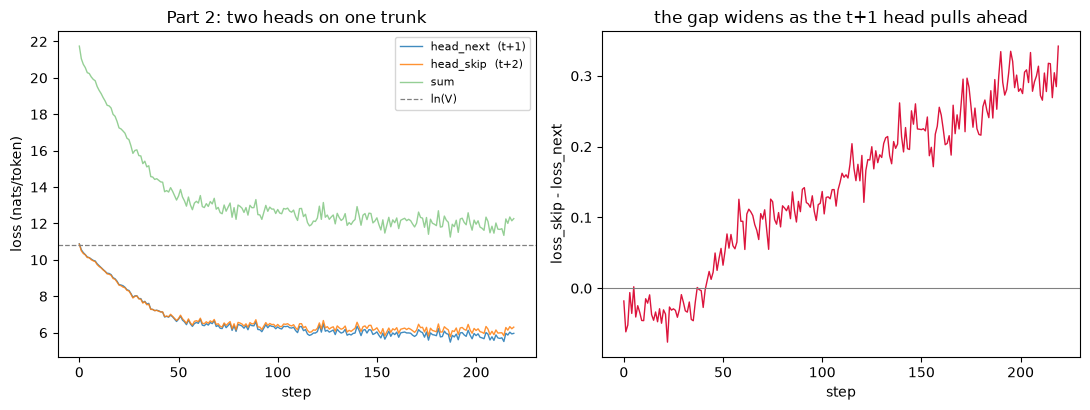

In [17]:
def tail(xs, k=20):
    return sum(xs[-k:]) / len(xs[-k:])

f_next, f_skip = tail(hist["next"]), tail(hist["skip"])
e_next, e_skip = tail(hist["next"][:20], 20), tail(hist["skip"][:20], 20)
print(f"{'':22}{'loss_next (t+1)':>18}{'loss_skip (t+2)':>18}{'gap':>10}")
print("-" * 68)
print(f"{'first 20 steps  ':22}{e_next:>18.4f}{e_skip:>18.4f}{e_skip-e_next:>+10.4f}")
print(f"{'last 20 steps   ':22}{f_next:>18.4f}{f_skip:>18.4f}{f_skip-f_next:>+10.4f}")
print(f"{'perplexity (last)':22}{math.exp(f_next):>18.1f}{math.exp(f_skip):>18.1f}")
print(f"\nsum of the two losses (last 20 steps): {tail(hist['sum']):.4f}")
print(f"total drop: next {e_next-f_next:.4f} nats, skip {e_skip-f_skip:.4f} nats")

plt.figure(figsize=(11, 4.2))
plt.subplot(1, 2, 1)
plt.plot(hist["next"], lw=1, alpha=.85, label="head_next  (t+1)")
plt.plot(hist["skip"], lw=1, alpha=.85, label="head_skip  (t+2)")
plt.plot(hist["sum"], lw=1, alpha=.5, label="sum")
plt.axhline(math.log(VOCAB_SIZE), ls="--", c="grey", lw=.9, label="ln(V)")
plt.xlabel("step"); plt.ylabel("loss (nats/token)"); plt.legend(fontsize=8)
plt.title("Part 2: two heads on one trunk")
plt.subplot(1, 2, 2)
gap = [s - n for s, n in zip(hist["skip"], hist["next"])]
plt.plot(gap, lw=1, c="crimson")
plt.axhline(0, c="grey", lw=.8)
plt.xlabel("step"); plt.ylabel("loss_skip - loss_next")
plt.title("the gap widens as the t+1 head pulls ahead")
plt.tight_layout(); plt.savefig("assets/part2_two_heads.png", dpi=130)
plt.show()

RESULTS["P2_loss_next"] = round(f_next, 4)
RESULTS["P2_loss_skip"] = round(f_skip, 4)
RESULTS["P2_loss_sum"] = round(f_next + f_skip, 4)
RESULTS["P2_gap_first20"] = round(e_skip - e_next, 4)
RESULTS["P2_gap_last20"] = round(f_skip - f_next, 4)

### What happens to the second head, and why

**What we see.** Both losses start at `ln(V)` and both fall. `loss_skip` is above
`loss_next` at every single step, and the **gap grows**: the two heads start nearly on top
of each other and separate as training proceeds.

**Why.** Early on, neither head knows anything; both are near uniform, so both sit at
`ln(V)` and the gap is ~0. The first thing a language model learns is cheap local structure -
the token after `Ġth` is `e`, the token after a newline in Shakespeare is a capitalised
speaker name. Nearly all of that structure is *immediately adjacent*, so it is available to
`head_next` and mostly destroyed by one step of distance for `head_skip`. `head_next`
therefore banks the easy wins first and pulls away.

There is a floor under `head_skip` that `head_next` does not have. Formally, the
t+2 head is modelling `p(x_{t+2} | x_<=t)`, which has marginalised out `x_{t+1}`:

> `H(x_{t+2} | x_<=t)  =  H(x_{t+2} | x_<=t+1)  +  I(x_{t+2} ; x_{t+1} | x_<=t)`

That second term - how much the unseen intervening token tells you about the one after it -
is strictly positive for real text, and no amount of training removes it. So `loss_skip`
cannot converge to `loss_next`; it converges to `loss_next` plus that mutual information.
The widening gap is the model discovering where that floor is.

**Why bother.** This is multi-token prediction (Gloeckle et al., 2024; used in DeepSeek-V3).
The extra head is not there to be good at `t+2` - it is a training signal. It forces the
residual stream at position `t` to carry information about the *near future* rather than
only the immediate next token, which is a denser gradient per forward pass and tends to
improve the `t+1` head. At inference the skip head is usually discarded, or used to draft
tokens for speculative decoding. Note also that we deliberately left `head_skip` **untied**:
tying it to `tok_emb` would put two different objectives on one matrix and let the `t+2`
task corrupt the input embeddings.

---
# Part 3 - The warning, reproduced

> *"A target shift in the incorrect direction can produce a beautiful loss curve."*

Three harnesses, identical in every other respect, differing only in which slice pairs with
which:

| variant | code | hidden at `i` is asked to predict |
|---|---|---|
| `delta=+1` **correct** | `logits[:, :-1]` vs `tokens[:, 1:]` | token `i+1` - not yet seen |
| `delta=0` **no shift** | `logits` vs `tokens` | token `i` - **already in its own input** |
| `delta=-1` **backwards** | `logits[:, 1:]` vs `tokens[:, :-1]` | token `i-1` - **already attended to** |

The two broken variants ask a causal model to reproduce a token it has **already been given**.
Copying is cheap, so the reported loss falls below the correct run's. Nothing raises.

The two do not fail equally, and the difference is worth watching for. `delta=0` only has to
echo the token sitting in its own residual stream, which is nearly free, so it plummets.
`delta=-1` has to learn an attention head that looks back exactly one position - easy, but
not free - so at this step budget it lands only slightly under the correct run.

**The subtle one is the more dangerous one.** A curve that collapses to near zero is obviously
suspicious and someone will investigate. A curve that sits a few percent below where it should
be looks like a good run. Nothing in the reported number distinguishes it. The strings do.

In [18]:
def train_variant(delta, steps=120, log_every=30):
    seed_all()
    m = TinyGPT().to(DEVICE)
    h = make_head(m, tied=True).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-4)
    curve = []
    for step in range(steps):
        tk = get_batch()
        lg = h(m(tk))
        if delta == 1:
            pl, tg = lg[:, :-1], tk[:, 1:]
        elif delta == 0:
            pl, tg = lg, tk
        elif delta == -1:
            pl, tg = lg[:, 1:], tk[:, :-1]
        loss = F.cross_entropy(pl.reshape(-1, VOCAB_SIZE), tg.reshape(-1))
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        curve.append(loss.item())
        if step % log_every == 0 or step == steps - 1:
            print(f"    step {step:3d}  loss {loss.item():7.4f}")
    return m, h, curve

VARIANTS = {"+1  correct": 1, " 0  no shift": 0, "-1  backwards": -1}
trained, curves = {}, {}
for name, d in VARIANTS.items():
    print(f"training delta = {name}")
    m, h, c = train_variant(d)
    trained[name] = (m, h); curves[name] = c
    print(f"  -> final loss {c[-1]:.4f}\n")

training delta = +1  correct


    step   0  loss 10.8533


    step  30  loss  7.7025


    step  60  loss  6.6204


    step  90  loss  6.1271


...

    step   0  loss 10.8578


    step  30  loss  7.7235


    step  60  loss  6.6542


    step  90  loss  6.0864


    step 119  loss  6.2157
  -> final loss 6.2157



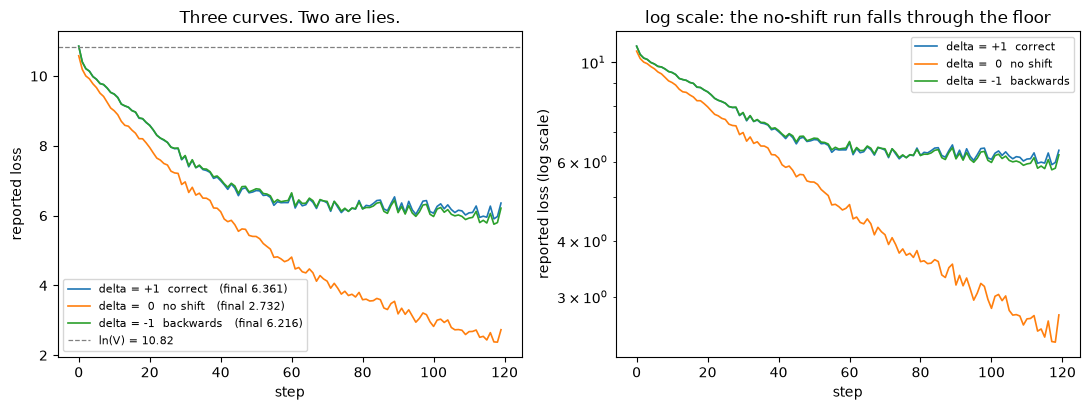

delta = +1  correct    final reported loss   6.3608   perplexity    578.712
delta =  0  no shift   final reported loss   2.7315   perplexity     15.356
delta = -1  backwards  final reported loss   6.2157   perplexity    500.525

The lowest reported loss belongs to '0  no shift'. Both broken variants report a LOWER
loss than the correct one. If the reported curve were your only instrument, you would
rank them above the run that is actually working.


In [19]:
plt.figure(figsize=(11, 4.2))
plt.subplot(1, 2, 1)
for name, c in curves.items():
    plt.plot(c, lw=1.2, label=f"delta = {name}   (final {c[-1]:.3f})")
plt.axhline(math.log(VOCAB_SIZE), ls="--", c="grey", lw=.9, label="ln(V) = 10.82")
plt.xlabel("step"); plt.ylabel("reported loss"); plt.legend(fontsize=8)
plt.title("Three curves. Two are lies.")
plt.subplot(1, 2, 2)
for name, c in curves.items():
    plt.semilogy(c, lw=1.2, label=f"delta = {name}")
plt.xlabel("step"); plt.ylabel("reported loss (log scale)"); plt.legend(fontsize=8)
plt.title("log scale: the no-shift run falls through the floor")
plt.tight_layout(); plt.savefig("assets/part3_shift_bug.png", dpi=130)
plt.show()

for name, c in curves.items():
    print(f"delta = {name:<14} final reported loss {c[-1]:8.4f}   "
          f"perplexity {math.exp(min(c[-1],700)):10.3f}")
_best = min(curves, key=lambda k: curves[k][-1])
print(f"\nThe lowest reported loss belongs to '{_best.strip()}'. Both broken variants report a "
      f"LOWER\nloss than the correct one. If the reported curve were your only instrument, you "
      "would\nrank them above the run that is actually working.")
RESULTS["P3_final_correct"] = round(curves["+1  correct"][-1], 4)
RESULTS["P3_final_noshift"] = round(curves[" 0  no shift"][-1], 4)
RESULTS["P3_final_backwards"] = round(curves["-1  backwards"][-1], 4)

### Catching it: print the strings

In [20]:
probe = get_batch(batch=1, block=16)[0]
for name, d in VARIANTS.items():
    print("=" * 74)
    if d == 1:
        show_shift(probe, delta=1, n=7, title=f"delta = {name}\n")
        print("  -> every target is a token the model has NOT been shown. Real prediction.\n")
    else:
        ids = probe.detach().cpu()
        if d == 0:
            inp, tgt = ids, ids
            note = "the target IS the input. The model reads token i and is graded on token i."
        else:
            inp, tgt = ids[1:], ids[:-1]
            note = "the target is the PREVIOUS token, which the model already attended to."
        si, st = tok_strings(inp), tok_strings(tgt)
        print(f"delta = {name}\n")
        print(f"{'pos':>4}  {'INPUT  logits row i reads this':<34}  {'TARGET  must predict this':<30}")
        print("-" * 74)
        for i in range(7):
            same = "  <-- IDENTICAL" if si[i] == st[i] else ""
            print(f"{i:>4}  {repr(si[i]):<34}  {repr(st[i]):<30}{same}")
        print(f"  -> {note}")
        print("     Copying is cheap, so the reported loss drops below the correct run's.")
        print("     The model does learn - it just learns to copy, which is not the task.\n")

delta = +1  correct

 pos  INPUT  logits row i reads this      TARGET  must predict this     
--------------------------------------------------------------------------
   0  ','                                 '␣that'                       
   1  '␣that'                             '␣Romeo'                      
   2  '␣Romeo'                            "'s"                          
   3  "'s"                                '␣faithful'                   
   4  '␣faithful'                         '␣wife'                       
   5  '␣wife'                             ':'                           
   6  ':'                                 '⏎'                           
  -> every target is a token the model has NOT been shown. Real prediction.

delta =  0  no shift

 pos  INPUT  logits row i reads this      TARGET  must predict this     
--------------------------------------------------------------------------
   0  ','                                 ','                            

### The decisive test: score every variant on the task that actually matters

The reported loss of a broken run is measured against its own broken target, so of course it
looks good. Evaluate all three models on the **correct** next-token objective and the
illusion dies.

In [21]:
seed_all(99)
eval_batches = [get_batch() for _ in range(6)]
print(f"{'variant':<16}{'reported loss':>16}{'TRUE next-token loss':>24}{'true ppl':>12}")
print("-" * 70)
true_losses = {}
for name, (m, h) in trained.items():
    m.eval(); h.eval()
    tot, cnt = 0.0, 0
    with torch.no_grad():
        for tk in eval_batches:
            lg = h(m(tk))
            tot += shifted_ce(lg, tk, reduction="sum").item()
            cnt += tk[:, 1:].numel()
    tl = tot / cnt
    true_losses[name] = tl
    print(f"{name:<16}{curves[name][-1]:>16.4f}{tl:>24.4f}{math.exp(min(tl,700)):>12.1f}")
print("-" * 70)
print(f"{'untrained ref':<16}{'-':>16}{gl:>24.4f}{gp:>12.1f}")
_corr = true_losses["+1  correct"]
print(f"\nln(V) = {math.log(VOCAB_SIZE):.4f} (untrained = {gl:.4f}).")
for _n in [" 0  no shift", "-1  backwards"]:
    print(f"  {_n.strip():<13} reported {curves[_n][-1]:7.4f} but is "
          f"{true_losses[_n]-_corr:+.4f} nats WORSE than the correct run on the real task.")
print("\nBoth broken runs did learn something - they beat the untrained model - but they "
      "learned\nthe wrong task, and their reported loss cannot tell you that. Only this "
      "column can.")
RESULTS["P3_true_correct"] = round(true_losses["+1  correct"], 4)
RESULTS["P3_true_noshift"] = round(true_losses[" 0  no shift"], 4)
RESULTS["P3_true_backwards"] = round(true_losses["-1  backwards"], 4)

variant            reported loss    TRUE next-token loss    true ppl
----------------------------------------------------------------------


+1  correct               6.3608                  6.1375       462.9


 0  no shift              2.7315                  8.3537      4246.0


-1  backwards             6.2157                  7.1036      1216.3
----------------------------------------------------------------------
untrained ref                  -                 10.8574     51917.5

ln(V) = 10.8249 (untrained = 10.8574).
  0  no shift   reported  2.7315 but is +2.2162 nats WORSE than the correct run on the real task.
  -1  backwards reported  6.2157 but is +0.9660 nats WORSE than the correct run on the real task.

Both broken runs did learn something - they beat the untrained model - but they learned
the wrong task, and their reported loss cannot tell you that. Only this column can.


---
# Summary - every number in the write-up, generated here

In [22]:
import json
print(json.dumps(RESULTS, indent=2, default=str))
with open("results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)

print("\n" + "=" * 78)
print("PART 1 - THE SEVEN NUMBERS")
print("=" * 78)
seven = [
    ("1. shapes",
     f"logits {RESULTS['1_shapes']['logits']} -> {RESULTS['1_rows']} rows x {VOCAB_SIZE} classes fed to CE"),
    ("2. shift on strings",
     f"target[i]==input[i+1] on every row: {RESULTS['2_offset_ok']}, mismatches {RESULTS['2_mismatches']}"),
    ("3. padding mask",
     f"contributing tokens {RESULTS['3_tokens_unmasked']} -> {RESULTS['3_tokens_masked']}   "
     f"(loss {RESULTS['3_loss_unmasked']} -> {RESULTS['3_loss_masked']})"),
    ("4. packing boundary",
     f"over {RESULTS['4agg_n_seams']} seams: loss {RESULTS['4agg_loss_with']} -> "
     f"{RESULTS['4agg_loss_without']}   (seam positions {RESULTS['4agg_seam_mean']} vs "
     f"interior {RESULTS['4agg_interior_mean']})"),
    ("5. untrained perplexity",
     f"{RESULTS['5_untrained_ppl']} vs V={VOCAB_SIZE}  (ratio {RESULTS['5_ppl_over_vocab']}, "
     f"loss {RESULTS['5_untrained_loss']} vs ln V {RESULTS['5_ln_vocab']})"),
    ("6. tied vs untied",
     f"{RESULTS['6_tied_params']:,} vs {RESULTS['6_untied_params']:,}   "
     f"(+{RESULTS['6_delta_params']:,} = V*D)"),
    ("7. peak memory",
     f"{RESULTS['7_peak_ordinary_mb']} MB ordinary vs {RESULTS['7_peak_chunked_mb']} MB chunked   "
     f"= {RESULTS['7_ratio']}x"),
]
for k, v in seven:
    print(f"  {k:<26} {v}")

print("\n" + "=" * 78)
print("PART 2 - TWO HEADS")
print("=" * 78)
_g0, _g1 = RESULTS['P2_gap_first20'], RESULTS['P2_gap_last20']
_dir = "WIDENS" if _g1 > _g0 else ("NARROWS" if _g1 < _g0 else "is flat")
print(f"  loss_next (t+1)  {RESULTS['P2_loss_next']}")
print(f"  loss_skip (t+2)  {RESULTS['P2_loss_skip']}")
print(f"  sum              {RESULTS['P2_loss_sum']}")
print(f"  gap              {_g0:+.4f} (first 20 steps) -> {_g1:+.4f} (last 20): "
      f"the gap {_dir}")
RESULTS["P2_gap_direction"] = _dir

print("\n" + "=" * 78)
print("PART 3 - THE WRONG-DIRECTION SHIFT")
print("=" * 78)
print(f"  {'variant':<16}{'reported':>12}{'true next-token':>18}")
for k, rep, tru in [("+1 correct", 'P3_final_correct', 'P3_true_correct'),
                    (" 0 no shift", 'P3_final_noshift', 'P3_true_noshift'),
                    ("-1 backwards", 'P3_final_backwards', 'P3_true_backwards')]:
    print(f"  {k:<16}{RESULTS[rep]:>12.4f}{RESULTS[tru]:>18.4f}")
_c_rep, _c_true = RESULTS['P3_final_correct'], RESULTS['P3_true_correct']
for _lbl, _rep, _true in [("no-shift", RESULTS['P3_final_noshift'], RESULTS['P3_true_noshift']),
                          ("backwards", RESULTS['P3_final_backwards'], RESULTS['P3_true_backwards'])]:
    _flatter = "BELOW" if _rep < _c_rep else "above"
    print(f"\n  {_lbl:<10} reports {_rep:.4f}, which is {_flatter} the correct run's "
          f"{_c_rep:.4f} -> looks as good or better,")
    print(f"  {'':<10} but its TRUE next-token loss is {_true:.4f} vs {_c_true:.4f}, "
          f"{_true - _c_true:+.4f} worse.")
print(f"\n  Both broken runs are still better than untrained ({RESULTS['5_untrained_loss']:.2f}) - "
      "they did learn something,")
print("  just not the task. Only the true-loss column separates them. Print the strings.")

{
  "1_rows": 60,
  "1_shapes": {
    "tokens": [
      4,
      16
    ],
    "hidden": [
      4,
      16,
      256
    ],
    "logits": [
      4,
      16,
      50257
    ],
    "pred_logits": [
      4,
      15,
      50257
    ],
    "targets": [
      4,
      15
    ],
    "flat_logits": [
      60,
      50257
    ],
    "flat_targets": [
      60
    ]
  },
  "2_offset_ok": true,
  "2_mismatches": 0,
  "3_tokens_unmasked": 24,
  "3_tokens_masked": 18,
  "3_loss_unmasked": 7.3775,
  "3_loss_masked": 5.2811,
  "4_loss_with_boundary": 8.867,
  "4_loss_without_boundary": 8.6823,
  "4_boundary_token_loss": 13.4828,
  "4agg_n_seams": 47,
  "4agg_seam_mean": 9.208,
  "4agg_interior_mean": 5.8235,
  "4agg_loss_with": 5.8591,
  "4agg_loss_without": 5.8235,
  "5_ln_vocab": 10.8249,
  "5_untrained_loss": 10.8574,
  "5_untrained_ppl": 51917.5,
  "5_ppl_over_vocab": 1.033,
  "5_buggy_ppl": "1.665e+73",
  "5_trained_ppl": 251.4,
  "6_tied_params": 16058112,
  "6_untied_params": 2892390